In [29]:
# !pip install torch yfinance numpy matplotlib arch pandas


In [30]:
#The setup
import yfinance as yf
from arch import arch_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

stock_choice = "AAPL"

data = yf.download(
    stock_choice,
    start="2000-01-01",
    end="2021-12-31",
    interval="1d",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [31]:
#train regime

#GARCH
scaling_factor = 100 #the model gave a low number error
prices = data["Close"]
returns = np.log(prices).diff().dropna()

train_returns = returns["2000-01-01":"2017-12-31"]
val_returns  = returns["2018-01-01":"2018-12-31"]
print(len(val_returns))

model = arch_model(train_returns * scaling_factor, vol="Garch", p=1, q=1)
res = model.fit()
#print(res.summary())


251
Iteration:      1,   Func. Count:      6,   Neg. LLF: 28215.354804017967
Iteration:      2,   Func. Count:     15,   Neg. LLF: 4049421.490247845
Iteration:      3,   Func. Count:     22,   Neg. LLF: 10143.657393265517
Iteration:      4,   Func. Count:     28,   Neg. LLF: 15868.12267285957
Iteration:      5,   Func. Count:     34,   Neg. LLF: 10070.380978062023
Iteration:      6,   Func. Count:     39,   Neg. LLF: 10337.961353251318
Iteration:      7,   Func. Count:     46,   Neg. LLF: 11055.781468033078
Iteration:      8,   Func. Count:     54,   Neg. LLF: 10069.9172093602
Iteration:      9,   Func. Count:     59,   Neg. LLF: 10069.859567065037
Iteration:     10,   Func. Count:     64,   Neg. LLF: 10069.858674669686
Iteration:     11,   Func. Count:     69,   Neg. LLF: 10069.85867070955
Iteration:     12,   Func. Count:     73,   Neg. LLF: 10069.858670710704
Optimization terminated successfully    (Exit mode 0)
            Current function value: 10069.85867070955
            Itera

In [32]:
#validation regime
horizon = 20

#GARCH
garch_preds = []
targets = []

history = train_returns.copy() * scaling_factor

for t in range(len(val_returns) - horizon):

    #GARCH Refit
    model = arch_model(history, p=1, q=1)
    res = model.fit(disp="off")
    forecast = res.forecast(horizon=horizon)
    var_forecast = forecast.variance.values[-1]
    garch_vol = np.sqrt(np.mean(var_forecast)) / scaling_factor
    garch_preds.append(garch_vol)

    #Ground Truth
    future = val_returns.iloc[t:t+horizon]
    realized_vol = np.std(future.values)
    targets.append(realized_vol)

    #new history
    history = pd.concat([history, val_returns.iloc[t:t+1]*scaling_factor])


GARCH MSE: 4.5644842678717786e-05


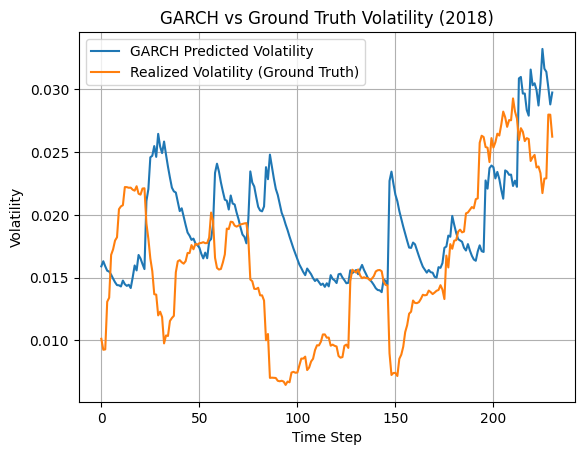

In [33]:
#MSE error

garch_pred_np = np.array(garch_preds)
targets_np = np.array(targets)
GARCH_MSE = np.mean((garch_pred_np - targets_np)**2)
print("GARCH MSE:", GARCH_MSE)
#print(len(garch_pred_np))

plt.plot(garch_preds, label="GARCH Predicted Volatility")
plt.plot(targets, label="Realized Volatility (Ground Truth)")

plt.title("GARCH vs Ground Truth Volatility (2018)")
plt.xlabel("Time Step")
plt.ylabel("Volatility")

plt.legend()
plt.grid(True)